In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [2]:
fund = pd.read_csv("E:/Project/data/processed/fund_master_clean.csv")
nav = pd.read_csv("E:/Project/data/processed/nav_history_clean.csv")
performance = pd.read_csv("E:/Project/data/processed/scheme_performance_clean.csv")
benchmark = pd.read_csv("E:/Project/data/processed/benchmark_indices_clean.csv")

In [3]:
print("Fund :", fund.shape)
print("NAV :", nav.shape)
print("Performance :", performance.shape)
print("Benchmark :", benchmark.shape)

Fund : (40, 15)
NAV : (46000, 3)
Performance : (40, 19)
Benchmark : (8050, 3)


In [4]:
nav["date"] = pd.to_datetime(nav["date"])

In [5]:
nav = nav.sort_values(
    by=["amfi_code", "date"]
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [7]:
nav[["amfi_code", "date", "nav", "daily_return"]].head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [8]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

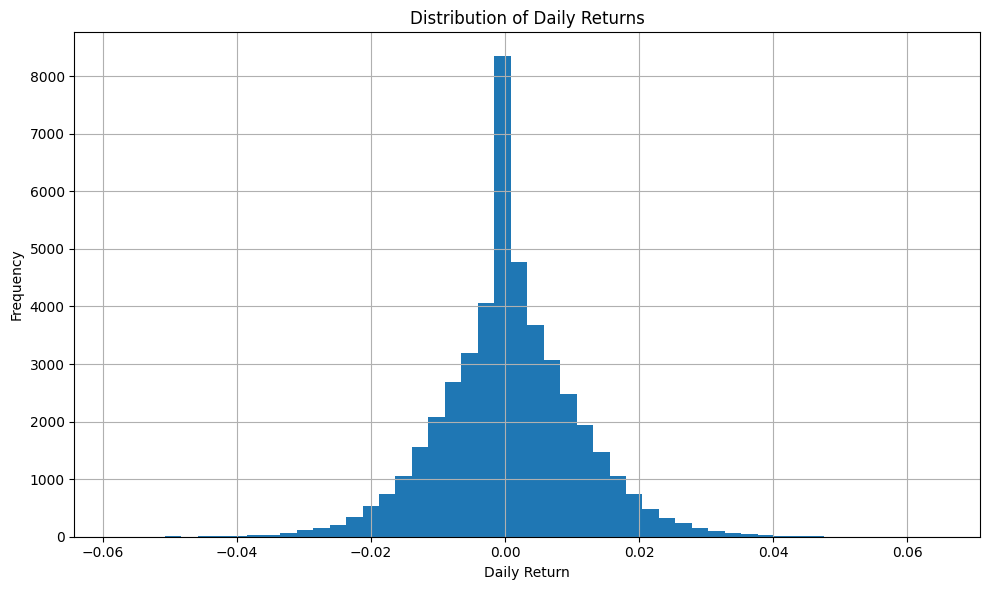

In [9]:
plt.figure(figsize=(10,6))
plt.hist(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    r"E:\Project\reports\charts\daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---

In [10]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [11]:
cagr_list = []

In [12]:
for code in nav["amfi_code"].unique():
    fund_data = nav[nav["amfi_code"] == code].copy()
    fund_data = fund_data.sort_values("date")
    end_date = fund_data["date"].max()
    end_nav = fund_data.iloc[-1]["nav"]
    start_1 = end_date - pd.DateOffset(years=1)
    nav_1 = fund_data[fund_data["date"] >= start_1].iloc[0]["nav"]
    cagr_1 = ((end_nav / nav_1) ** (1/1) - 1) * 100
    start_3 = end_date - pd.DateOffset(years=3)
    nav_3 = fund_data[fund_data["date"] >= start_3].iloc[0]["nav"]
    cagr_3 = ((end_nav / nav_3) ** (1/3) - 1) * 100
    start_5 = end_date - pd.DateOffset(years=5)
    nav_5 = fund_data.iloc[0]["nav"]
    if len(fund_data[fund_data["date"] >= start_5]) > 0:
        nav_5 = fund_data[fund_data["date"] >= start_5].iloc[0]["nav"]
    cagr_5 = ((end_nav / nav_5) ** (1/5) - 1) * 100
    cagr_list.append([
        code,
        cagr_1,
        cagr_3,
        cagr_5
    ])

In [13]:
cagr = pd.DataFrame(
    cagr_list,
    columns=[
        "amfi_code",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
)

In [14]:
cagr = pd.merge(
    cagr,
    fund[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

In [15]:
comparison_table = cagr[
    [
        "scheme_name",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
]

comparison_table = comparison_table.sort_values(
    by="cagr_5yr",
    ascending=False
)

comparison_table

,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
25,ICICI Pru Midcap Fund - Regular - Growth,29.604659,31.777537,28.376762
21,SBI Small Cap Fund - Regular Plan - Growth,82.776059,26.669922,28.033224
39,DSP Small Cap Fund - Regular - Growth,65.138719,27.000427,27.917430
36,Mirae Asset Tax Saver Fund - Regular - Growth,39.751761,29.178902,27.629860
34,Mirae Asset Large Cap Fund - Regular - Growth,20.360678,34.000916,26.799277
30,Kotak Flexicap Fund - Regular - Growth,26.657082,29.582770,26.742494
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,26.074068
38,DSP Midcap Fund - Regular - Growth,21.481222,26.869991,25.611807
16,Axis Midcap Fund - Regular - Growth,22.261065,35.111802,24.445309
19,SBI Bluechip Fund - Regular Plan - Growth,60.437341,30.456524,22.384873


In [16]:
comparison_table.to_csv(
    "E:/Project/data/processed/cagr_comparison.csv",
    index=False
)

---

In [17]:
rf = 0.065

In [18]:
sharpe = nav.groupby("amfi_code").agg(average_return=("daily_return","mean"),risk=("daily_return","std")).reset_index()

sharpe.head()

,amfi_code,average_return,risk
0,100016,0.000142,0.009164
1,100025,0.000170,0.002460
2,100033,0.001080,0.011929
3,101206,0.000852,0.009177
4,101207,0.000424,0.016251


In [19]:
sharpe["sharpe_ratio"] = ((sharpe["average_return"] - (rf/252)) / sharpe["risk"]) * np.sqrt(252)

sharpe.head()

,amfi_code,average_return,risk,sharpe_ratio
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661


In [20]:
sharpe = pd.merge(sharpe,fund[["amfi_code","scheme_name"]],on="amfi_code")

In [21]:
sharpe = sharpe.sort_values(by="sharpe_ratio",ascending=False)
sharpe["rank"] = range(1, len(sharpe)+1)
sharpe.head(10)

,amfi_code,average_return,risk,sharpe_ratio,scheme_name,rank
34,148567,0.001074,0.008941,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,1
30,120843,0.001082,0.010008,1.306744,Kotak Flexicap Fund - Regular - Growth,2
36,148569,0.001124,0.011134,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,3
19,119551,0.000917,0.008656,1.208267,SBI Bluechip Fund - Regular Plan - Growth,4
25,120505,0.001161,0.012152,1.180101,ICICI Pru Midcap Fund - Regular - Growth,5
38,149323,0.001055,0.011179,1.132122,DSP Midcap Fund - Regular - Growth,6
2,100033,0.001080,0.011929,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,7
9,118632,0.000865,0.008913,1.081659,Nippon India Large Cap Fund - Regular - Growth,8
3,101206,0.000852,0.009177,1.027213,ABSL Frontline Equity Fund - Regular - Growth,9
24,120504,0.000843,0.009048,1.026524,ICICI Pru Bluechip Fund - Direct - Growth,10


In [22]:
sharpe.to_csv("E:/project/data/processed/sharpe_ratio.csv",index=False)

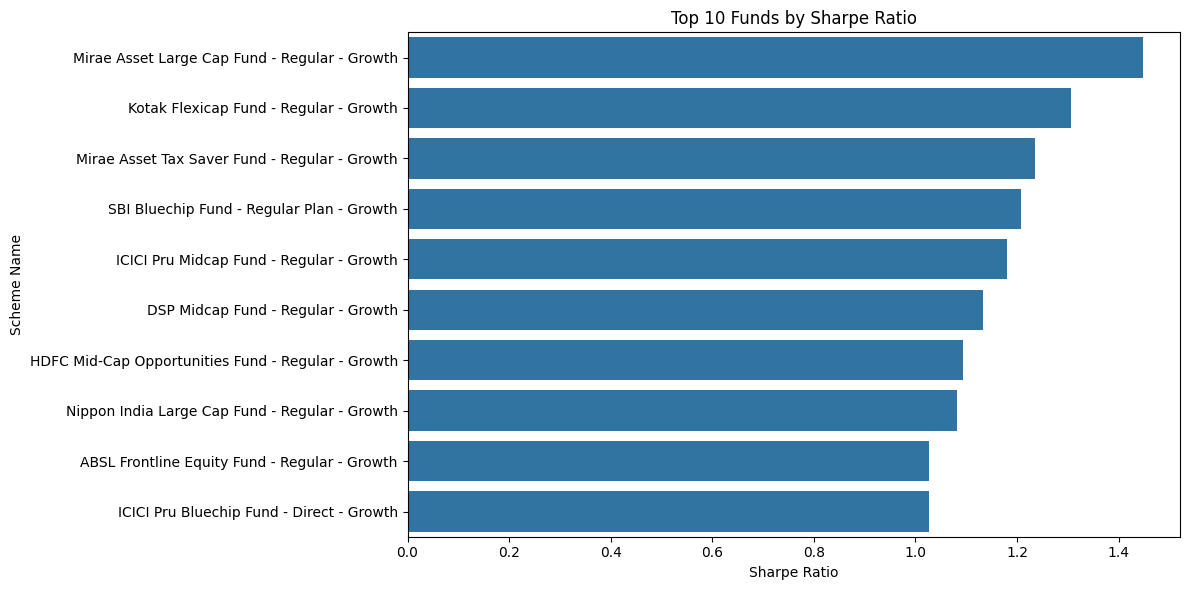

In [23]:
top10 = sharpe.head(10)
plt.figure(figsize=(12,6))
sns.barplot(data=top10,x="sharpe_ratio",y="scheme_name")

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Scheme Name")
plt.tight_layout()
plt.savefig( r"E:\Project\reports\charts\sharpe_ratio.png",dpi=300,bbox_inches="tight")

plt.show()

---

In [24]:
rf = 0.065

In [25]:
sortino_list = []

In [26]:
for code in nav["amfi_code"].unique():
    fund_data = nav[nav["amfi_code"] == code]
    average_return = fund_data["daily_return"].mean()
    downside_returns = fund_data[fund_data["daily_return"] < 0 ]["daily_return"]
    downside_std = downside_returns.std()
    sortino_ratio = ((average_return - (rf / 252)) / downside_std) * np.sqrt(252)
    sortino_list.append([code, sortino_ratio])

In [27]:
sortino = pd.DataFrame( sortino_list,columns=[
        "amfi_code",
        "sortino_ratio"])

sortino.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [28]:
sortino = pd.merge(sortino,fund[["amfi_code", "scheme_name"]],on="amfi_code")

sortino.head()

,amfi_code,sortino_ratio,scheme_name
0,100016,-0.351047,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.941821,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.276644,ABSL Small Cap Fund - Regular - Growth


In [29]:
sortino = sortino.sort_values(by="sortino_ratio",ascending=False)
sortino["rank"] = range(1,len(sortino)+1)

sortino.head(10)

,amfi_code,sortino_ratio,scheme_name,rank
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth,1
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth,2
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth,3
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth,4
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth,5
38,149323,1.875101,DSP Midcap Fund - Regular - Growth,6
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth,7
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,8
24,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth,9
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth,10


In [30]:
sortino.to_csv("E:/project/data/processed/sortino_ratio.csv",index=False)

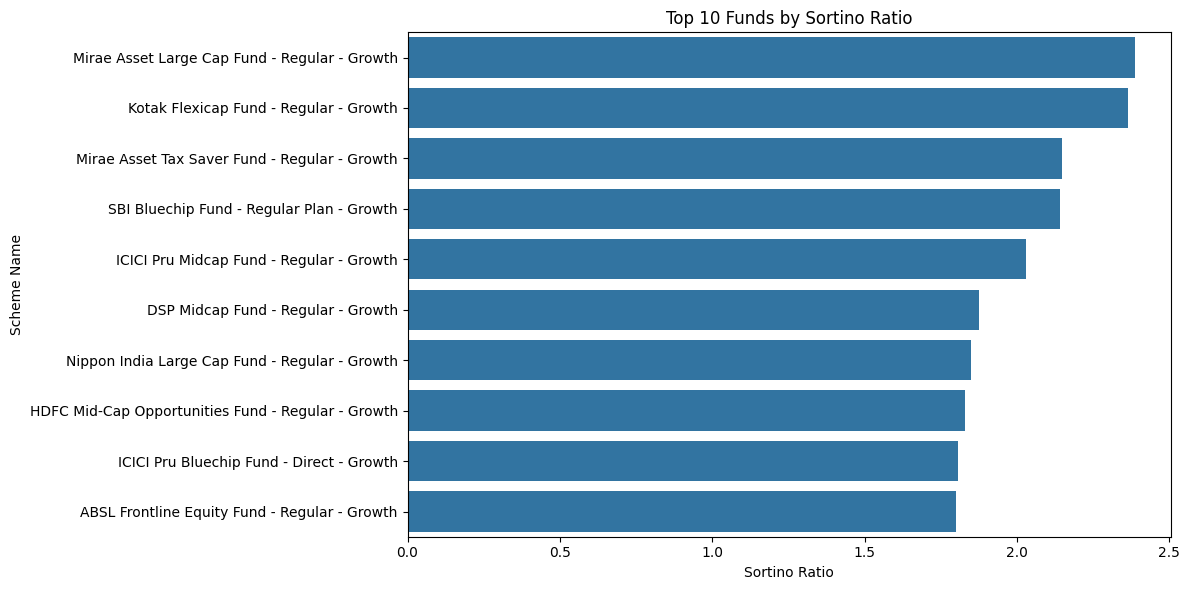

In [31]:
top10 = sortino.head(10)
plt.figure(figsize=(12,6))
sns.barplot(data=top10,x="sortino_ratio",y="scheme_name")
plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("Sortino Ratio")
plt.ylabel("Scheme Name")
plt.tight_layout()
plt.savefig(r"E:\Project\reports\charts\sortino_ratio.png",dpi=300,bbox_inches="tight")

plt.show()

---

In [32]:
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [33]:
nifty100["date"] = pd.to_datetime(nifty100["date"])

nifty100 = nifty100.sort_values("date")

In [34]:
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [35]:
alpha_beta = []

In [36]:
for code in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == code
    ].copy()

    merged = pd.merge(
        fund_data,
        nifty100[["date","benchmark_return"]],
        on="date"
    )

    merged = merged.dropna()

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252

    beta = slope

    alpha_beta.append(
        [code, alpha, beta]
    )

In [37]:
alpha_beta = pd.DataFrame(alpha_beta,columns=[
        "amfi_code",
        "alpha",
        "beta"])

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [38]:
alpha_beta = pd.merge(alpha_beta,fund[["amfi_code","scheme_name"]],on="amfi_code")
alpha_beta.head()

,amfi_code,alpha,beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [43]:
alpha_beta = pd.merge(
    alpha_beta,
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

alpha_beta.head()

,amfi_code,alpha,beta,scheme_name_x,scheme_name_y,scheme_name
0,119598,0.303370,-0.023196,SBI Small Cap Fund - Regular Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth
1,149324,0.300579,0.011455,DSP Small Cap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth
2,120505,0.292636,0.000549,ICICI Pru Midcap Fund - Regular - Growth,ICICI Pru Midcap Fund - Regular - Growth,ICICI Pru Midcap Fund - Regular - Growth
3,148569,0.282704,0.018134,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset Tax Saver Fund - Regular - Growth
4,120843,0.273305,-0.022830,Kotak Flexicap Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth


In [40]:
alpha_beta.to_csv(
    "E:/project/data/processed/alpha_beta.csv",
    index=False
)

In [41]:
alpha_beta = alpha_beta.sort_values(by="alpha",ascending=False)

alpha_beta.head(10)

,amfi_code,alpha,beta,scheme_name_x,scheme_name_y
21,119598,0.303370,-0.023196,SBI Small Cap Fund - Regular Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.300579,0.011455,DSP Small Cap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth
25,120505,0.292636,0.000549,ICICI Pru Midcap Fund - Regular - Growth,ICICI Pru Midcap Fund - Regular - Growth
36,148569,0.282704,0.018134,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset Tax Saver Fund - Regular - Growth
30,120843,0.273305,-0.022830,Kotak Flexicap Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
34,148567,0.269838,0.023684,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset Large Cap Fund - Regular - Growth
38,149323,0.265986,-0.002523,DSP Midcap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth
16,119094,0.260767,-0.066265,Axis Midcap Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth
19,119551,0.232010,-0.031751,SBI Bluechip Fund - Regular Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth


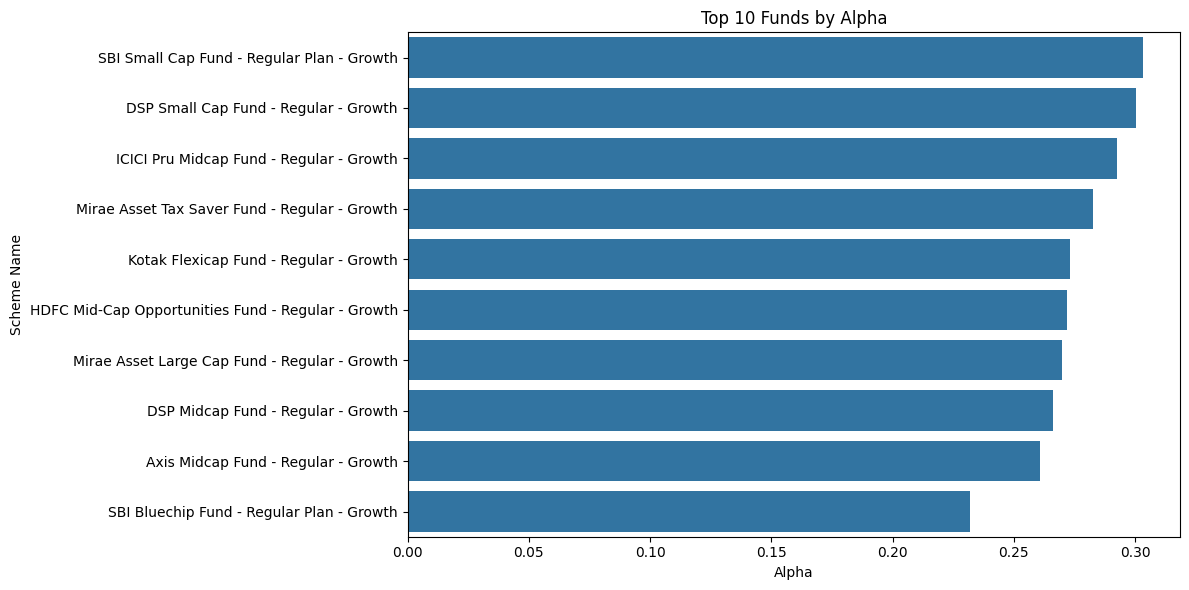

In [44]:
plt.figure(figsize=(12,6))

top10 = alpha_beta.sort_values(
    by="alpha",
    ascending=False
).head(10)

sns.barplot(
    data=top10,
    x="alpha",
    y="scheme_name"
)

plt.title("Top 10 Funds by Alpha")
plt.xlabel("Alpha")
plt.ylabel("Scheme Name")

plt.tight_layout()
plt.show()

---

In [45]:
drawdown_list = []

In [46]:
drawdown_list = []

for code in nav["amfi_code"].unique():
    fund_data = nav[nav["amfi_code"] == code].copy()
    fund_data = fund_data.sort_values("date")
    fund_data["running_max"] = fund_data["nav"].cummax()
    fund_data["drawdown"] = (fund_data["nav"] / fund_data["running_max"]) - 1

    max_drawdown = fund_data["drawdown"].min()
    
    trough_date = fund_data.loc[fund_data["drawdown"].idxmin(),"date"]
    peak_data = fund_data[fund_data["date"] <= trough_date]
    peak_date = peak_data.loc[peak_data["nav"].idxmax(),"date"]
    drawdown_list.append([
        code,
        peak_date,
        trough_date,
        max_drawdown
    ])

In [47]:
drawdown = pd.DataFrame(
    drawdown_list,
    columns=[
        "amfi_code",
        "peak_date",
        "trough_date",
        "max_drawdown"
    ]
)

drawdown.head()

,amfi_code,peak_date,trough_date,max_drawdown
0,100016,2022-03-30,2022-09-15,-0.247344
1,100025,2023-05-23,2023-07-28,-0.043083
2,100033,2022-03-11,2022-05-12,-0.162172
3,101206,2023-04-24,2023-07-05,-0.112916
4,101207,2024-11-21,2026-05-11,-0.354469


In [48]:
drawdown = pd.merge(
    drawdown,
    fund[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

drawdown.head()

,amfi_code,peak_date,trough_date,max_drawdown,scheme_name
0,100016,2022-03-30,2022-09-15,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,2023-05-23,2023-07-28,-0.043083,HDFC Short Term Debt Fund - Regular - Growth
2,100033,2022-03-11,2022-05-12,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,2023-04-24,2023-07-05,-0.112916,ABSL Frontline Equity Fund - Regular - Growth
4,101207,2024-11-21,2026-05-11,-0.354469,ABSL Small Cap Fund - Regular - Growth


In [49]:
drawdown = drawdown.sort_values(
    by="max_drawdown"
)

drawdown.head(10)

,amfi_code,peak_date,trough_date,max_drawdown,scheme_name
22,119599,2023-01-17,2025-10-28,-0.525742,SBI Small Cap Fund - Direct Plan - Growth
17,119095,2025-05-22,2026-05-11,-0.516778,Axis Small Cap Fund - Regular - Growth
4,101207,2024-11-21,2026-05-11,-0.354469,ABSL Small Cap Fund - Regular - Growth
39,149324,2024-05-03,2025-01-03,-0.311719,DSP Small Cap Fund - Regular - Growth
21,119598,2024-08-28,2025-05-14,-0.287060,SBI Small Cap Fund - Regular Plan - Growth
7,102886,2025-01-07,2026-04-27,-0.280011,UTI Mid Cap Fund - Regular - Growth
0,100016,2022-03-30,2022-09-15,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,2023-11-09,2024-10-17,-0.240035,Kotak Emerging Equity Fund - Regular - Growth
11,118634,2025-04-09,2026-02-20,-0.233449,Nippon India Small Cap Fund - Regular - Growth
15,119093,2022-02-24,2023-05-22,-0.217514,Axis Bluechip Fund - Direct - Growth


In [50]:
drawdown.to_csv(
    "E:/project/data/processed/max_drawdown.csv",
    index=False
)

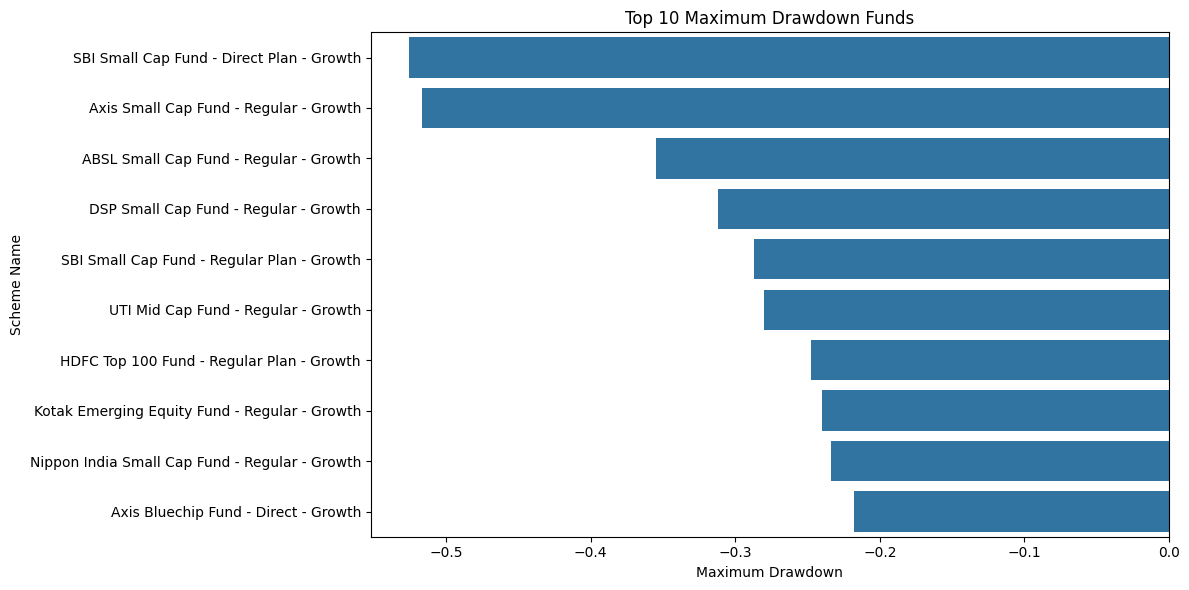

In [51]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=drawdown.head(10),
    x="max_drawdown",
    y="scheme_name")
plt.title("Top 10 Maximum Drawdown Funds")
plt.xlabel("Maximum Drawdown")
plt.ylabel("Scheme Name")
plt.tight_layout()
plt.savefig(
    r"E:\Project\reports\charts\max_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---

In [52]:
score = performance.copy()

score.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [53]:
score["return_rank"] = score["return_3yr_pct"].rank(
    ascending=False,
    method="min"
)

score["sharpe_rank"] = score["sharpe_ratio"].rank(ascending=False,method="min")

score["alpha_rank"] = score["alpha"].rank(ascending=False,method="min")

score["expense_rank"] = score["expense_ratio_pct"].rank(ascending=True,method="min")

score["drawdown_rank"] = score["max_drawdown_pct"].rank(ascending=False,method="min")

In [54]:
score["raw_score"] = (

    score["return_rank"] * 0.30 +

    score["sharpe_rank"] * 0.25 +

    score["alpha_rank"] * 0.20 +

    score["expense_rank"] * 0.15 +

    score["drawdown_rank"] * 0.10

)

In [55]:
score["fund_score"] = ((score["raw_score"].max() - score["raw_score"]) / (score["raw_score"].max() - score["raw_score"].min())) * 100

In [56]:
score = score.sort_values(
    by="fund_score",
    ascending=False
)

score.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,expense_ratio_pct,morningstar_rating,risk_grade,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,raw_score,fund_score
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,1.45,5,Moderately High,11.0,11.0,3.0,22.0,20.0,11.95,100.00
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,...,0.74,5,Low,35.0,1.0,3.0,7.0,3.0,12.70,96.25
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,1.43,5,Very High,1.0,18.0,20.0,21.0,8.0,12.75,96.00
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,...,0.56,3,Low,36.0,4.0,1.0,2.0,6.0,12.90,95.25
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,...,1.56,4,High,7.0,14.0,2.0,33.0,25.0,13.45,92.50
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,0.72,4,Very High,2.0,19.0,22.0,5.0,30.0,13.50,92.25
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,1.46,5,Moderate,17.0,7.0,12.0,23.0,15.0,14.20,88.75
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,1.53,5,Very High,3.0,24.0,5.0,28.0,27.0,14.80,85.75
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,...,0.60,3,Low,37.0,2.0,14.0,3.0,5.0,15.35,83.00
33,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Flexi Cap,Regular,17.43,15.34,15.78,13.55,1.79,...,1.64,5,Moderately High,13.0,14.0,8.0,39.0,7.0,15.55,82.00


In [57]:
score.to_csv(
    "E:/project/data/processed/fund_scorecard.csv",
    index=False
)

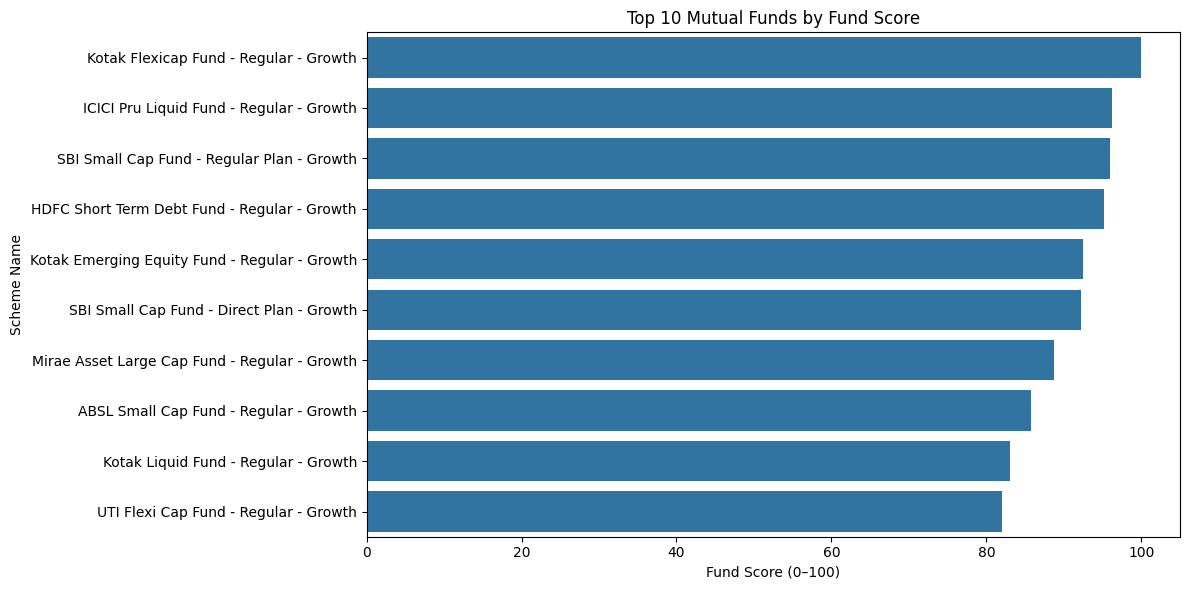

In [58]:
plt.figure(figsize=(12,6))

top10 = score.head(10)

sns.barplot(
    data=top10,
    x="fund_score",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds by Fund Score")
plt.xlabel("Fund Score (0–100)")
plt.ylabel("Scheme Name")
plt.tight_layout()
plt.savefig(
    r"E:\Project\reports\charts\fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---

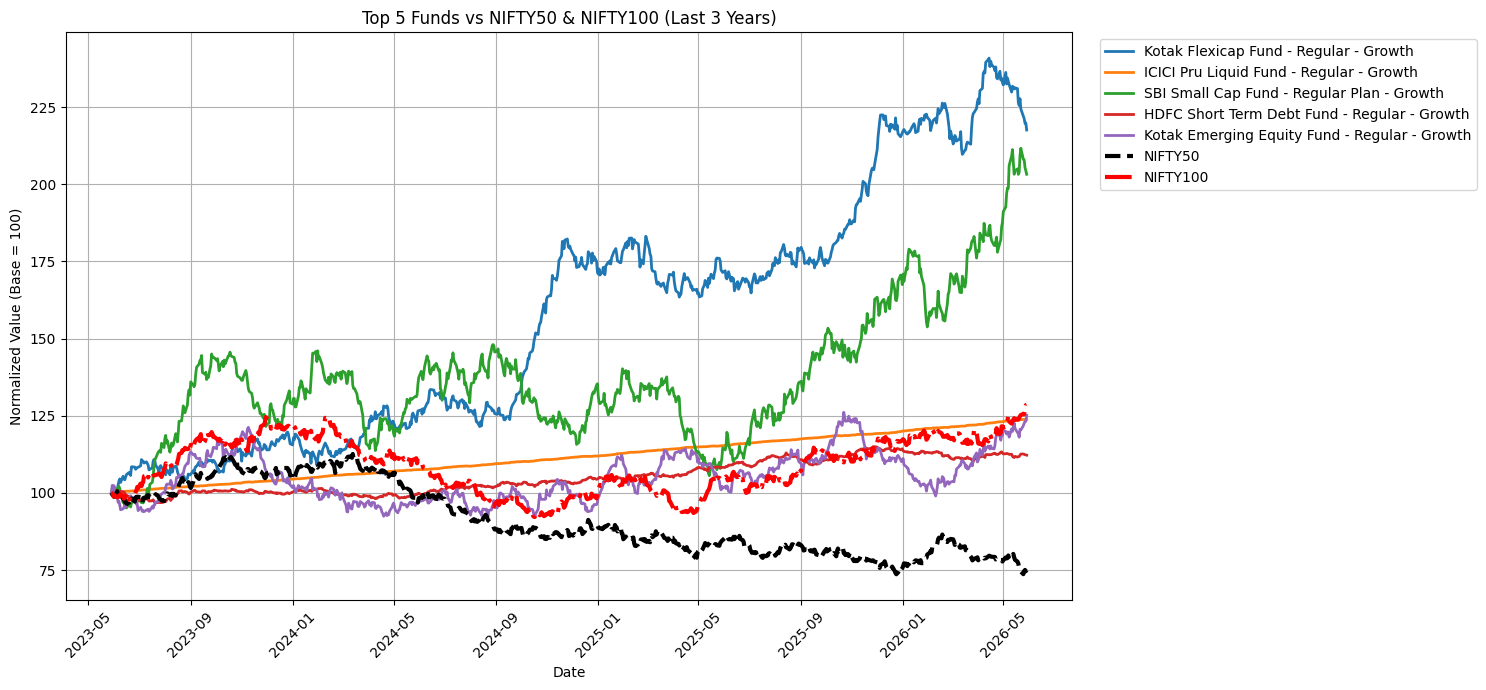

,scheme_name,tracking_error
0,Kotak Flexicap Fund - Regular - Growth,0.206540
1,ICICI Pru Liquid Fund - Regular - Growth,0.127924
2,SBI Small Cap Fund - Regular Plan - Growth,0.286689
3,HDFC Short Term Debt Fund - Regular - Growth,0.133673
4,Kotak Emerging Equity Fund - Regular - Growth,0.220454


In [59]:
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])


end_date = nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

top5 = score.nlargest(5, "fund_score")

nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"].copy()

nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty50 = nifty50[nifty50["date"] >= start_date]
nifty100 = nifty100[nifty100["date"] >= start_date]


nifty50["index"] = (nifty50["close_value"] /nifty50["close_value"].iloc[0]) * 100

nifty100["index"] = (nifty100["close_value"] /nifty100["close_value"].iloc[0]) * 100


plt.figure(figsize=(15,7))
tracking_error = []
for _, row in top5.iterrows():

    code = row["amfi_code"]
    name = row["scheme_name"]

    fund_data = nav[nav["amfi_code"] == code].copy()
    fund_data = fund_data.sort_values("date")
    fund_data = fund_data[fund_data["date"] >= start_date]

    if fund_data.empty:
        print(f"No data found for {name}")
        continue

    fund_data["index"] = (fund_data["nav"] /fund_data["nav"].iloc[0]) * 100

    plt.plot(
        fund_data["date"],
        fund_data["index"],
        linewidth=2,
        label=name
    )

 
    fund_data["fund_return"] = fund_data["nav"].pct_change()

    bench = pd.merge(
        fund_data,
        nifty100[["date", "close_value"]],
        on="date",
        how="inner"
    )

    bench["benchmark_return"] = bench["close_value"].pct_change()
    bench = bench.dropna()

    te = (bench["fund_return"] -bench["benchmark_return"]).std() * np.sqrt(252)
    tracking_error.append([name, te])


plt.plot(
    nifty50["date"],
    nifty50["index"],
    color="black",
    linewidth=3,
    linestyle="--",
    label="NIFTY50")

plt.plot(
    nifty100["date"],
    nifty100["index"],
    color="red",
    linewidth=3,
    linestyle="-.",
    label="NIFTY100")


plt.title("Top 5 Funds vs NIFTY50 & NIFTY100 (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig(
    r"E:\Project\reports\charts\benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

tracking_error = pd.DataFrame(
    tracking_error,
    columns=[
        "scheme_name",
        "tracking_error"])

tracking_error.to_csv(
    "E:/project/data/processed/tracking_error.csv",
    index=False
)

tracking_error